## Paper

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from predhpc import paper
from predhpc.util import plot_util

%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
paper.initialize_paper_parameters(gen_dir="..", notebook=True)
ALL_FIGURES = dict()

### Fig. 1: Background

In [4]:
Pyrs = paper.get_linear_Pyrs()

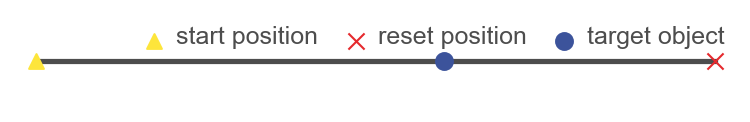

In [5]:
sub_ax = paper.plot_environment(Ag=Pyrs.Agent)
ALL_FIGURES["1B"] = sub_ax

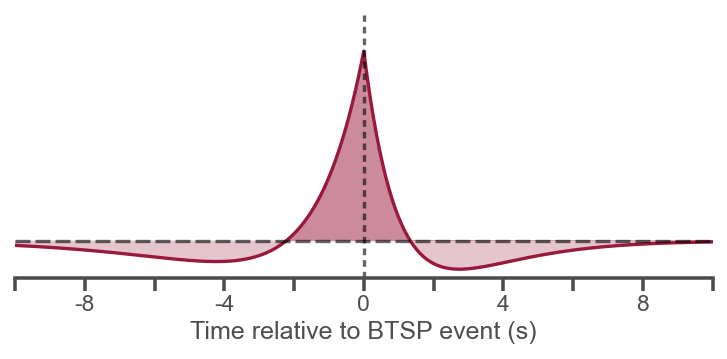

In [6]:
sub_ax = paper.plot_BTSP_kernel(Pyrs)
ALL_FIGURES["1D"] = sub_ax

### Fig. 2: Linear track

In [7]:
learner = paper.run_linear(max_time_min=1.8)

 17%|██████▊                                | 629/3600 [00:00<00:03, 852.83it/s]

BTSP event recorded at step 513 (15.39 sec).


 37%|██████████████▏                       | 1344/3600 [00:01<00:02, 879.80it/s]

BTSP update applied at step 1207 (36.21 sec).


100%|██████████████████████████████████████| 3600/3600 [00:04<00:00, 856.30it/s]


Finishing last trajectory.


1131it [00:01, 849.02it/s]

Only reached target 4 times (target: 10).
Trajectory lengths (5) to date: 28.39 +/- 15.36 sec each
Trajectory lengths (5) to date: 946.40 +/- 511.95 steps each
1 BTSP event triggered (allowed from steps 0 to 4731): occurred at step 513.


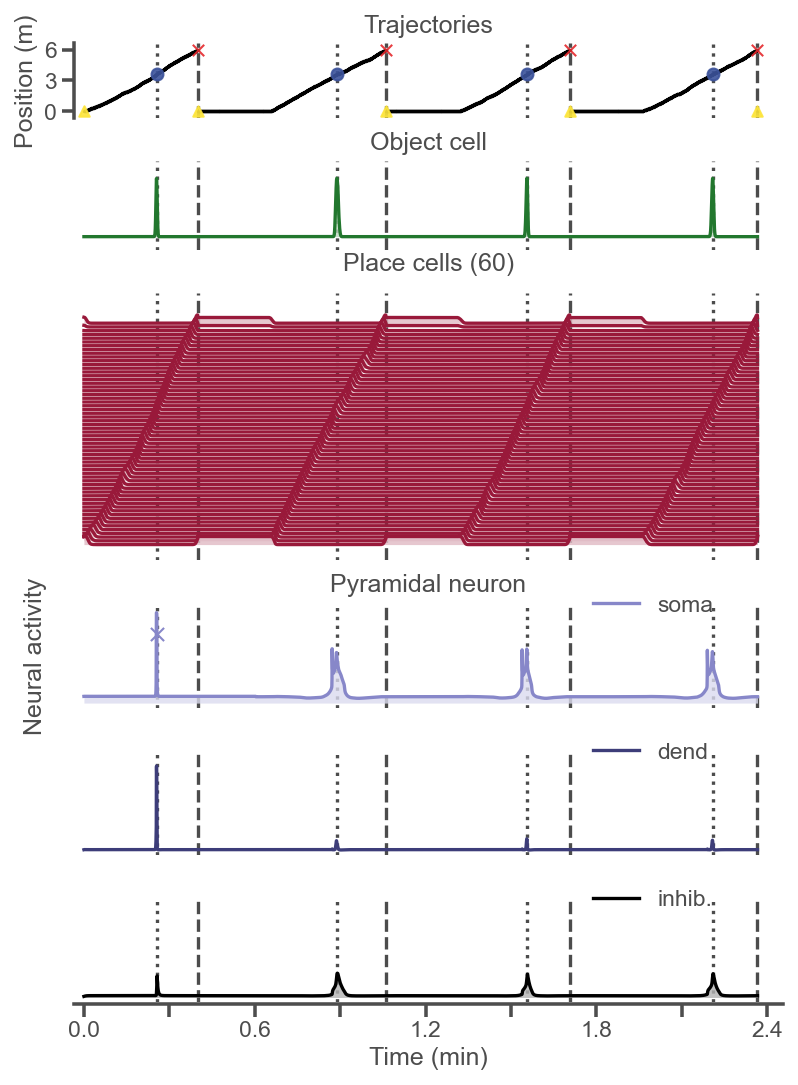

In [8]:
ax1D = paper.plot_linear_summary(learner)
ALL_FIGURES["2A"] = ax1D

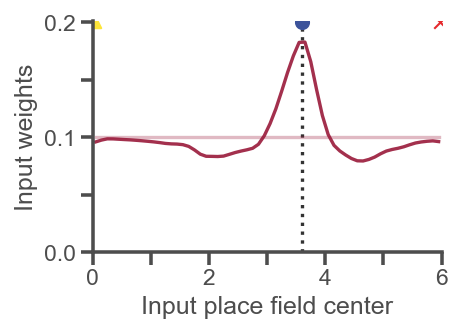

In [9]:
sub_ax = paper.plot_linear_PFs(learner)
ALL_FIGURES["2B"] = sub_ax

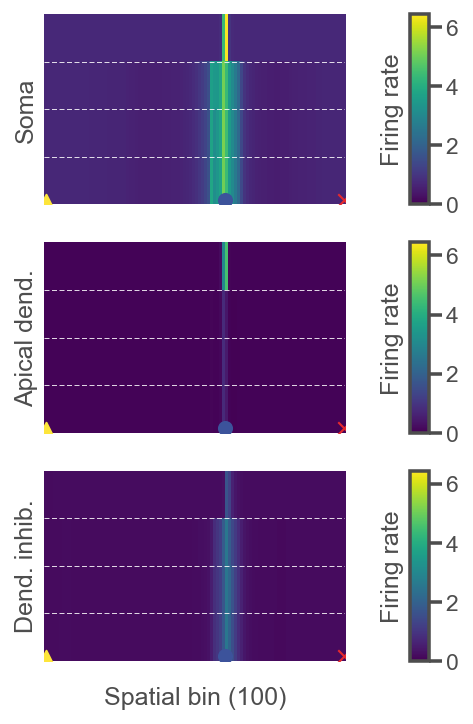

In [10]:
ax1D = paper.plot_linear_binned_rates(learner)
ALL_FIGURES["2C"] = ax1D

### Fig. 3: Speed and PF width
Takes about 2.5 min to rerun.

In [11]:
speed_data = paper.run_linear_fct("linear_speeds", overwrite=False)

Loading data from ../results/paper/speed_data_18.npz.


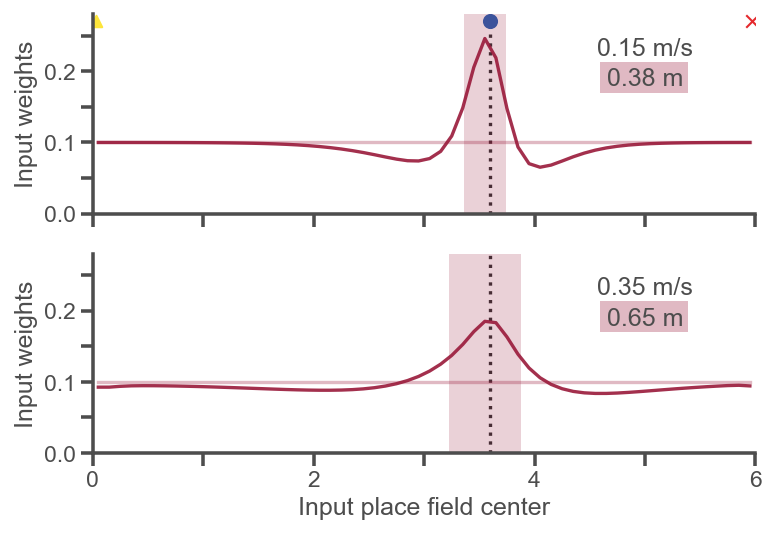

In [12]:
ax1D = paper.plot_linear_speed_PF_examples(speed_data)
ALL_FIGURES["3A"] = ax1D

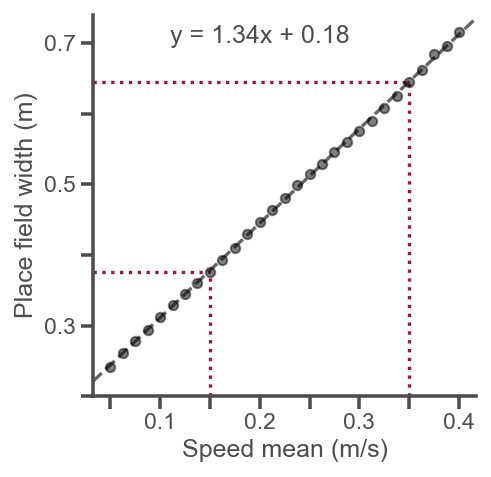

In [13]:
sub_ax = paper.plot_linear_speed_PF_widths(speed_data)
ALL_FIGURES["3B"] = sub_ax

### Fig. 4: Effect of linear shifts
Takes about 5 min to rerun.

In [14]:
shift_data = paper.run_linear_fct("linear_shifts", overwrite=False)

Loading data from ../results/paper/shift_data_18.npz.


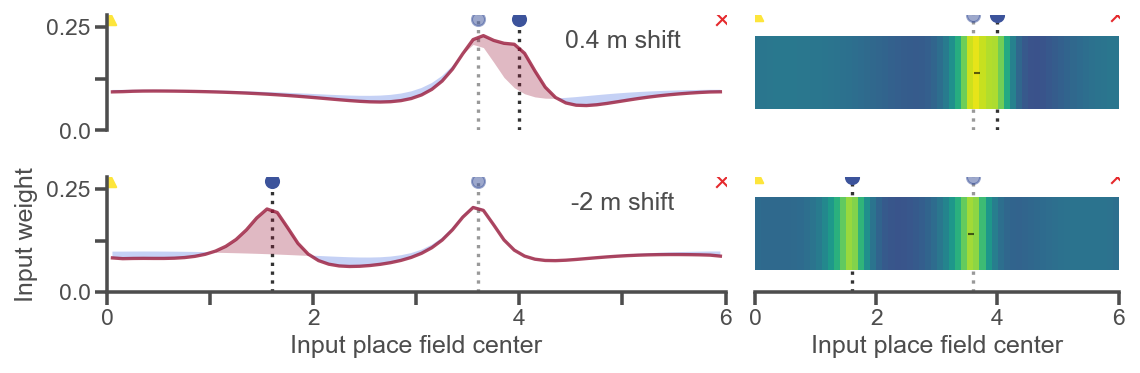

In [15]:
axes = paper.plot_linear_shift_PF_examples(shift_data)
ALL_FIGURES["4A"] = axes

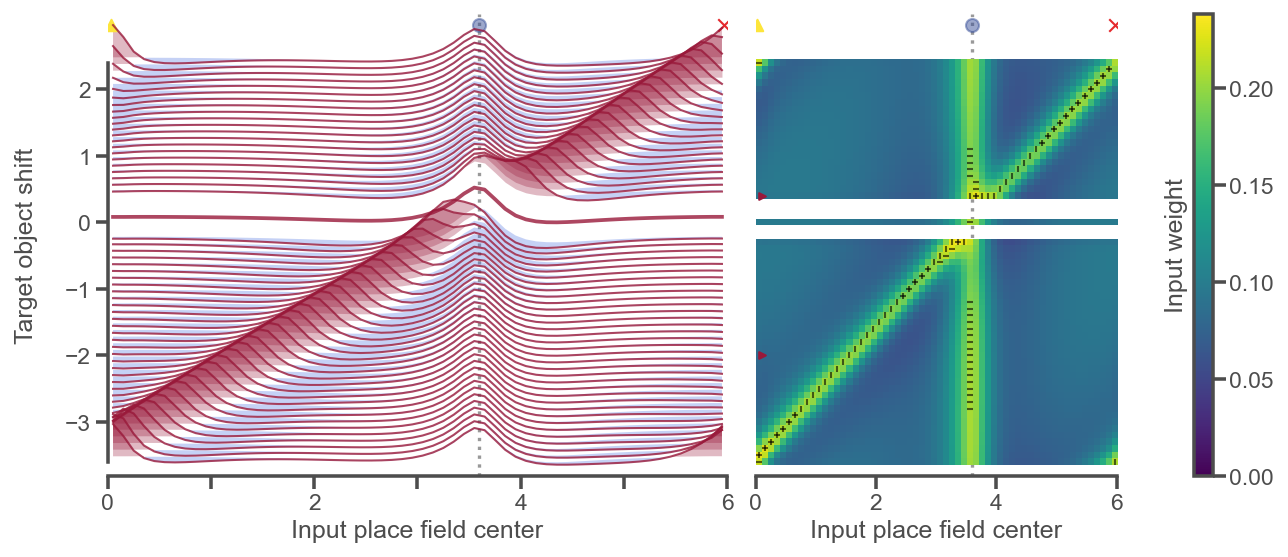

In [16]:
ax1D = paper.plot_target_shift_PFs(shift_data)
ALL_FIGURES["4B"] = ax1D

### Fig. 5: 2D environment and teleportation

In [41]:
import copy

from predhpc import plot_fcts, run_manager
from predhpc.util import params_util, gen_util, ext_util

In [19]:
gen_util.seed_all(paper.PAPER_SEED)

Pyr_params = params_util.get_Pyr_params(
    environment="openfield_corridor",
    log_BTSP=True
)

learner = run_manager.learn_openfield_BTSP(
    Pyr_params=Pyr_params,
    corridor=True,
    max_num_steps=15000,
    weight_recording_freq=1000,
    teleportation_enabled=False,
)

  8%|██▊                                  | 1156/15000 [00:03<00:39, 348.31it/s]

BTSP event recorded at step 1095 (32.85 sec).


 12%|████▌                                | 1841/15000 [00:05<00:35, 375.71it/s]

BTSP update applied at step 1789 (53.67 sec).


100%|████████████████████████████████████| 15000/15000 [00:36<00:00, 408.00it/s]

Reached target 27 times.
Trajectory lengths (8) to date: 56.25 +/- 9.92 sec each
Trajectory lengths (8) to date: 1875.00 +/- 330.72 steps each
1 BTSP event triggered (allowed from steps 0 to 14999): occurred at step 1095.


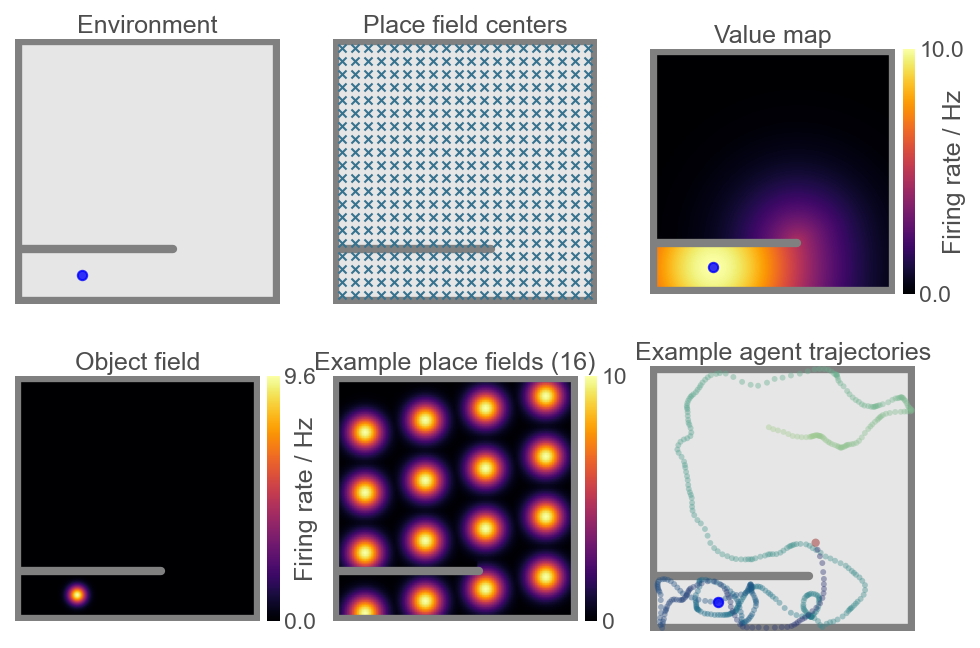

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(6, 4))
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(learner.Pyrs)
updater = run_manager.VNUpdater(Ag)

kwargs = {
    "skip_object_types": ["teleport"],
    "no_legend": True
}

axes[0, 0].set_title("Environment")
Env.plot_environment(sub_ax=axes[0, 0], **kwargs)

axes[1, 0].set_title("Object field")
Objs.plot_rate_map(sub_ax=axes[1, 0], plot_objects=False, **kwargs)

axes[0, 1].set_title("Place field centers")
PCs.plot_place_cell_locations(sub_ax=axes[0, 1], plot_objects=False, **kwargs)
n, skip = 16, 25
chosen_neurons = np.arange(int(n * skip))[2::skip]

axes[1, 1].set_title(f"Example place fields ({n})")
Env.plot_environment(sub_ax=axes[1, 1], plot_objects=False, **kwargs)
plot_fcts.plot_overlayed_rate_maps(PCs, sub_ax=axes[1, 1], method="max", chosen_neurons=chosen_neurons)

axes[0, 2].set_title("Value map")
updater.VN.plot_rate_map(ax=axes[0, 2], **kwargs)

axes[1, 2].set_title("Example agent trajectories")
traj_idx = 4
t_start = Ag.trajectory_df.loc[traj_idx, "start_time"] + 1
t_end = Ag.trajectory_df.loc[traj_idx, "stop_time"]
t_end = min(t_end, t_start + 90)
Ag.plot_trajectories(sub_ax=axes[1, 2], t_start=t_start, t_end=t_end, framerate=8, alpha=0.4, s_2D=8, cmap_per=True, plot_target=False, plot_agent=False, **kwargs);

### Fig. 6: Multiple targets

### Save figures

In [19]:
SAVE = True

In [20]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, no_timestamp=True)

Saving 9 figures...
Figure saved to /home/colleen/Documents/predhpc/results/paper/1B.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/1D.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/2A.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/2B.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/2C.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/3A.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/3B.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/4A.png  & .svg
Figure saved to /home/colleen/Documents/predhpc/results/paper/4B.png  & .svg
